Matplotlib — Task Sheet

Part A — build each core plot type

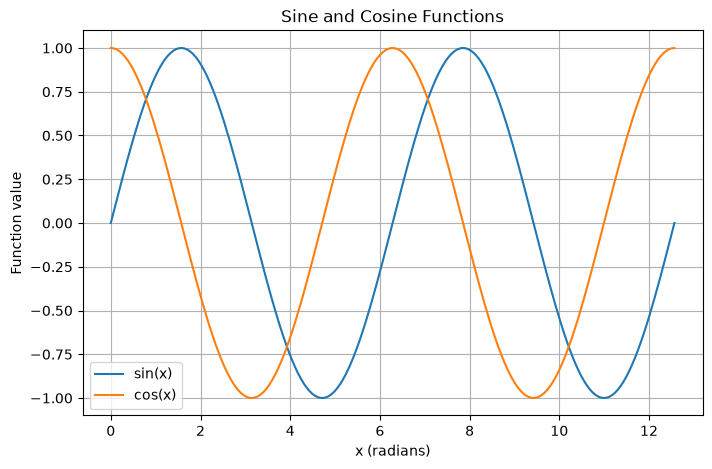

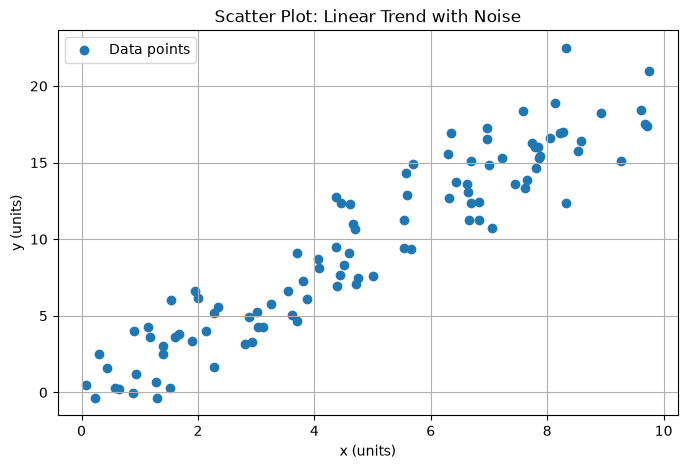

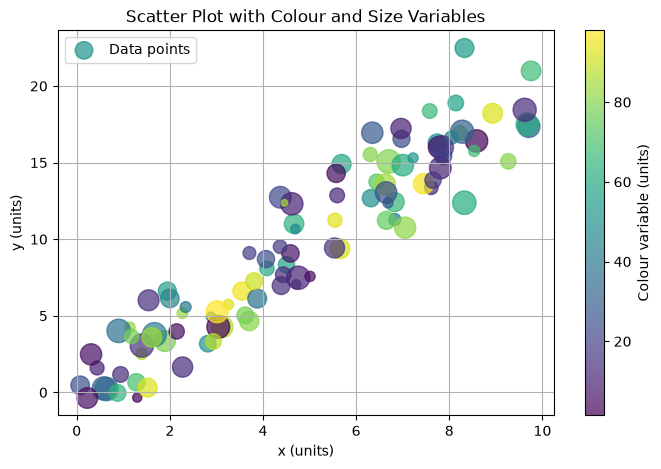

In [1]:
# TASK 01
# Line and scatter

import numpy as np
import matplotlib.pyplot as plt

# Reproducible random data
rng = np.random.default_rng(42)

# ---------------------------------------------------------
# 1. Line plot: sin(x) and cos(x)
# ---------------------------------------------------------

x = np.linspace(0, 4 * np.pi, 200)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")

ax.set_title("Sine and Cosine Functions")
ax.set_xlabel("x (radians)")
ax.set_ylabel("Function value")
ax.legend()
ax.grid(True)

plt.show()


# ---------------------------------------------------------
# 2. Scatter plot: y ≈ 2x + noise
# ---------------------------------------------------------

x_scatter = rng.uniform(0, 10, 100)
noise = rng.normal(0, 2, 100)
y_scatter = 2 * x_scatter + noise

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x_scatter, y_scatter, label="Data points")

ax.set_title("Scatter Plot: Linear Trend with Noise")
ax.set_xlabel("x (units)")
ax.set_ylabel("y (units)")
ax.legend()
ax.grid(True)

plt.show()


# ---------------------------------------------------------
# Rule:
# ---------------------------------------------------------
# Use a line plot when data points have an ordered/continuous
# relationship, such as temperature over time or loss over epochs.
#
# Use a scatter plot when showing the relationship between
# individual observations, such as study hours vs exam marks
# in machine learning.


# ---------------------------------------------------------
# 3. Scatter plot with colour and size
# ---------------------------------------------------------

colour_variable = rng.uniform(0, 100, 100)
size_variable = rng.uniform(20, 300, 100)

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x_scatter,
    y_scatter,
    c=colour_variable,
    s=size_variable,
    alpha=0.7,
    label="Data points",
)

ax.set_title("Scatter Plot with Colour and Size Variables")
ax.set_xlabel("x (units)")
ax.set_ylabel("y (units)")
ax.legend()

fig.colorbar(scatter, ax=ax, label="Colour variable (units)")

ax.grid(True)

plt.show()

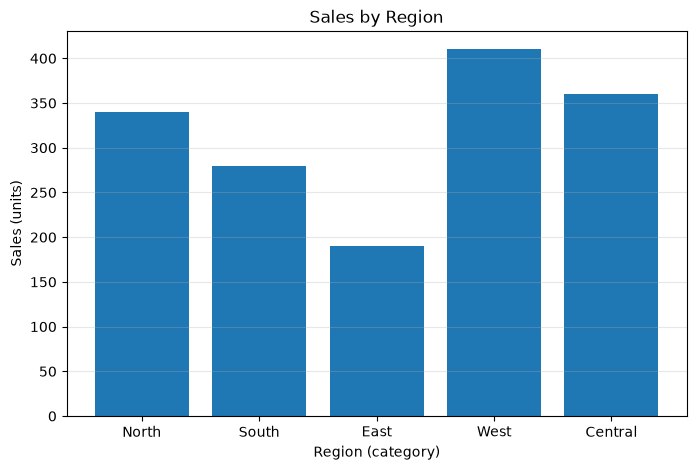

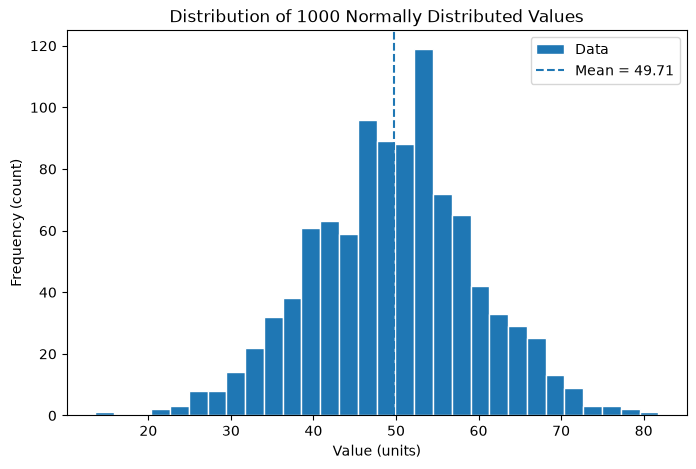

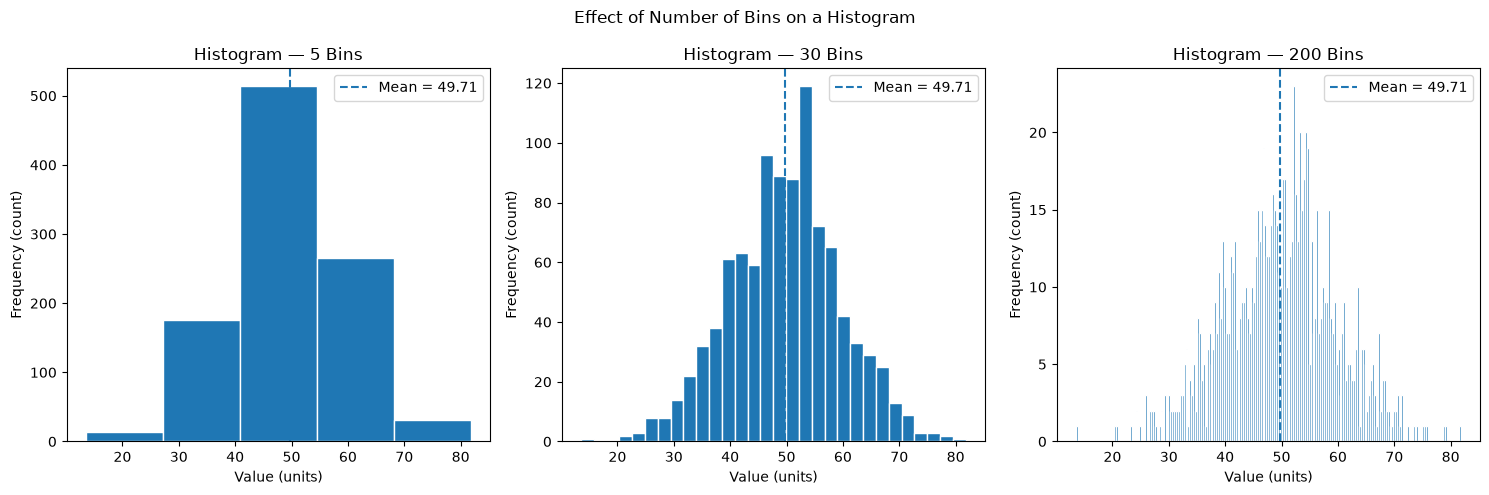

In [3]:
# TASK 02
# Bar chart versus histogram

import numpy as np
import matplotlib.pyplot as plt

# Reproducible random data
rng = np.random.default_rng(42)

# =========================================================
# 1. Bar chart — values across categories
# =========================================================

regions = ["North", "South", "East", "West", "Central"]
sales = [340, 280, 190, 410, 360]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(regions, sales)

ax.set_title("Sales by Region")
ax.set_xlabel("Region (category)")
ax.set_ylabel("Sales (units)")
ax.grid(axis="y", alpha=0.3)

plt.show()


# =========================================================
# 2. Histogram — distribution of one variable
# =========================================================

data = rng.normal(loc=50, scale=10, size=1000)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(data, bins=30, edgecolor="white", label="Data")

ax.axvline(
    data.mean(),
    linestyle="--",
    label=f"Mean = {data.mean():.2f}",
)

ax.set_title("Distribution of 1000 Normally Distributed Values")
ax.set_xlabel("Value (units)")
ax.set_ylabel("Frequency (count)")
ax.legend()

plt.show()


# =========================================================
# Difference between bar chart and histogram
# =========================================================

# A bar chart compares separate categories, so gaps between
# bars show that the categories are distinct.
#
# A histogram shows the distribution of a continuous numerical
# variable. Its bins represent adjacent ranges of values, so
# the bars touch because the ranges are continuous.


# =========================================================
# 3. Same data with 5, 30, and 200 bins
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bin_values = [5, 30, 200]

for ax, bins in zip(axes, bin_values):
    ax.hist(data, bins=bins, edgecolor="white")
    
    ax.axvline(
        data.mean(),
        linestyle="--",
        label=f"Mean = {data.mean():.2f}",
    )
    
    ax.set_title(f"Histogram — {bins} Bins")
    ax.set_xlabel("Value (units)")
    ax.set_ylabel("Frequency (count)")
    ax.legend()

fig.suptitle("Effect of Number of Bins on a Histogram")
fig.tight_layout()

plt.show()


# 30 bins tells the story best because it gives enough detail
# to see the shape of the normal distribution without making
# the histogram too coarse or too noisy.

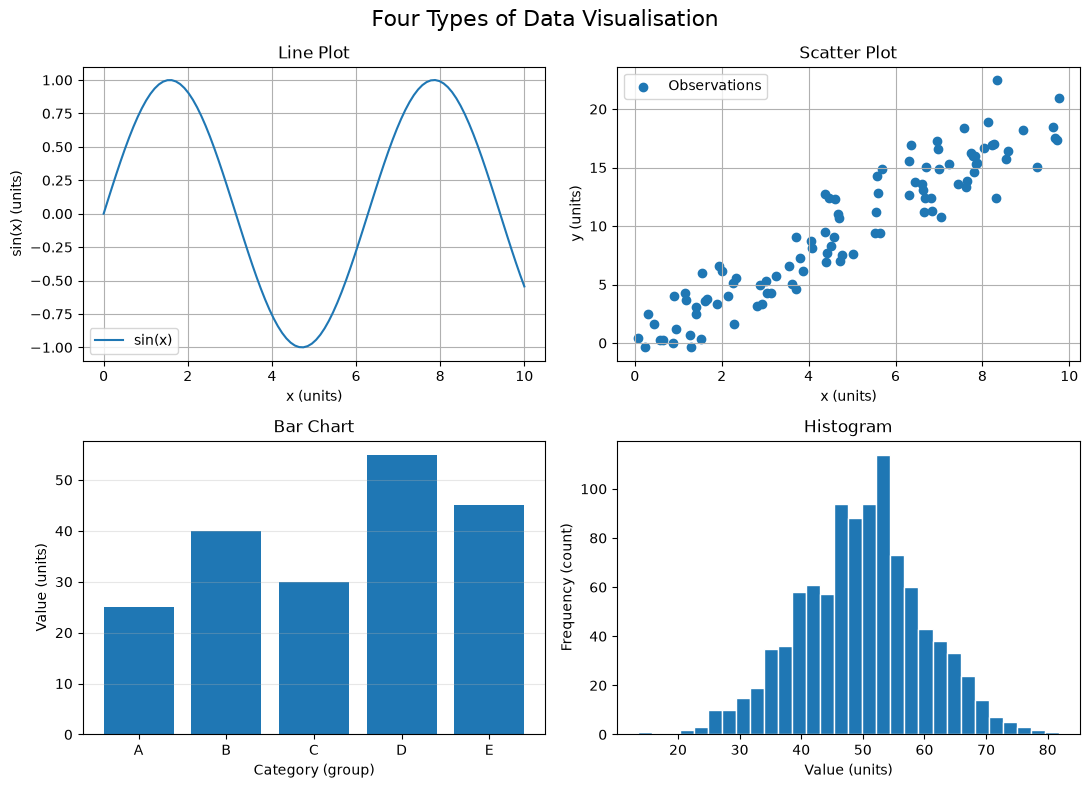

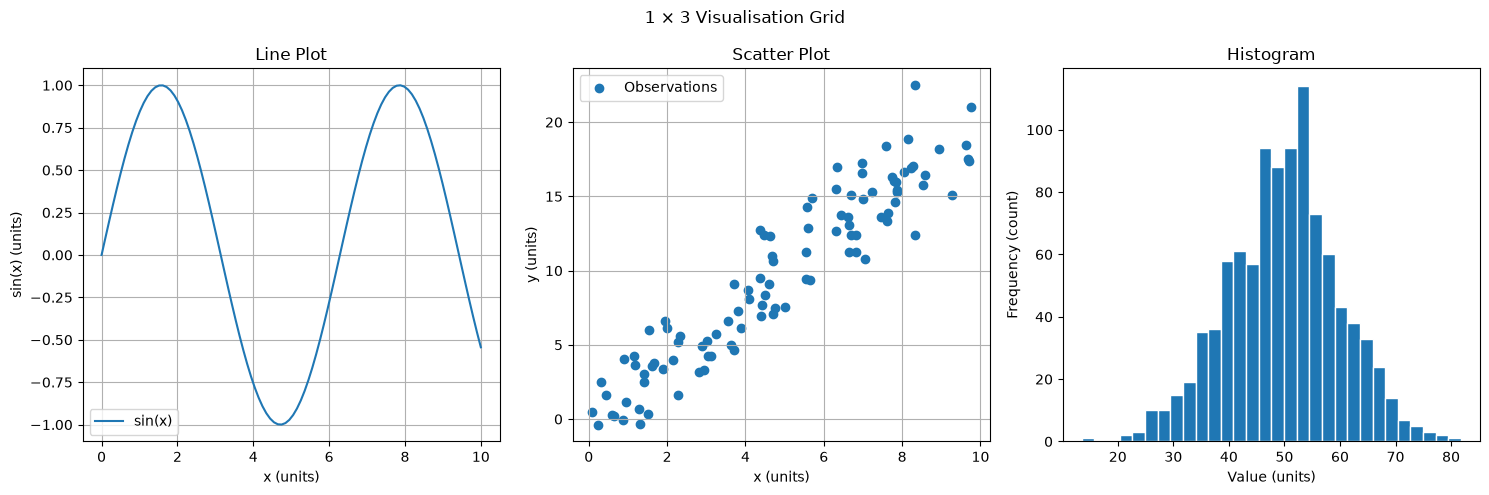

In [4]:
# TASK 03
# Subplots — a grid that tells one story

import numpy as np
import matplotlib.pyplot as plt

# Reproducible random data
rng = np.random.default_rng(42)

# =========================================================
# 1. Create data
# =========================================================

x = np.linspace(0, 10, 100)
y_line = np.sin(x)

x_scatter = rng.uniform(0, 10, 100)
y_scatter = 2 * x_scatter + rng.normal(0, 2, 100)

categories = ["A", "B", "C", "D", "E"]
values = [25, 40, 30, 55, 45]

hist_data = rng.normal(loc=50, scale=10, size=1000)


# =========================================================
# 2. Create 2 × 2 subplot grid
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# ---------------------------------------------------------
# Top-left: Line plot
# ---------------------------------------------------------

axes[0, 0].plot(x, y_line, label="sin(x)")

axes[0, 0].set_title("Line Plot")
axes[0, 0].set_xlabel("x (units)")
axes[0, 0].set_ylabel("sin(x) (units)")
axes[0, 0].legend()
axes[0, 0].grid(True)


# ---------------------------------------------------------
# Top-right: Scatter plot
# ---------------------------------------------------------

axes[0, 1].scatter(x_scatter, y_scatter, label="Observations")

axes[0, 1].set_title("Scatter Plot")
axes[0, 1].set_xlabel("x (units)")
axes[0, 1].set_ylabel("y (units)")
axes[0, 1].legend()
axes[0, 1].grid(True)


# ---------------------------------------------------------
# Bottom-left: Bar chart
# ---------------------------------------------------------

axes[1, 0].bar(categories, values)

axes[1, 0].set_title("Bar Chart")
axes[1, 0].set_xlabel("Category (group)")
axes[1, 0].set_ylabel("Value (units)")
axes[1, 0].grid(axis="y", alpha=0.3)


# ---------------------------------------------------------
# Bottom-right: Histogram
# ---------------------------------------------------------

axes[1, 1].hist(hist_data, bins=30, edgecolor="white")

axes[1, 1].set_title("Histogram")
axes[1, 1].set_xlabel("Value (units)")
axes[1, 1].set_ylabel("Frequency (count)")


# =========================================================
# 3. Whole figure title
# =========================================================

fig.suptitle("Four Types of Data Visualisation", fontsize=16)

# Try commenting this line out to see the difference.
# tight_layout() prevents subplot labels and titles from
# overlapping.
plt.tight_layout()

plt.show()


# =========================================================
# 4. 1 × 3 subplot grid
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# First subplot
axes[0].plot(x, y_line, label="sin(x)")
axes[0].set_title("Line Plot")
axes[0].set_xlabel("x (units)")
axes[0].set_ylabel("sin(x) (units)")
axes[0].legend()
axes[0].grid(True)


# Second subplot
axes[1].scatter(x_scatter, y_scatter, label="Observations")
axes[1].set_title("Scatter Plot")
axes[1].set_xlabel("x (units)")
axes[1].set_ylabel("y (units)")
axes[1].legend()
axes[1].grid(True)


# Third subplot
axes[2].hist(hist_data, bins=30, edgecolor="white")
axes[2].set_title("Histogram")
axes[2].set_xlabel("Value (units)")
axes[2].set_ylabel("Frequency (count)")


fig.suptitle("1 × 3 Visualisation Grid")

plt.tight_layout()

plt.show()


# =========================================================
# Explanation of indexing
# =========================================================

# In a 2 × 2 grid, axes is a 2-dimensional array,
# so we use two indices:
# axes[row, column]
#
# Example:
# axes[0, 0] -> top-left
# axes[0, 1] -> top-right
# axes[1, 0] -> bottom-left
# axes[1, 1] -> bottom-right
#
# In a 1 × 3 grid, axes is a 1-dimensional array,
# so only one index is needed:
# axes[0], axes[1], axes[2]
#
# This happens because there is only one row of subplots.

Part B — judgment, not just mechanics

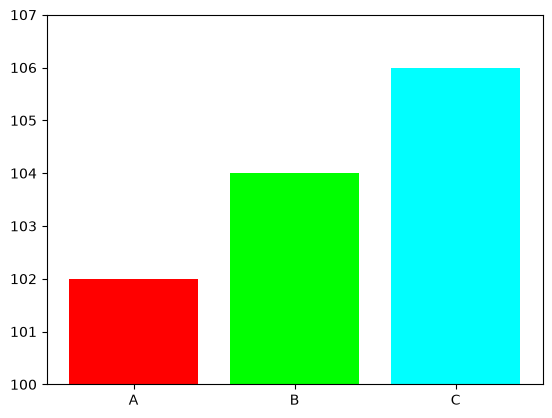

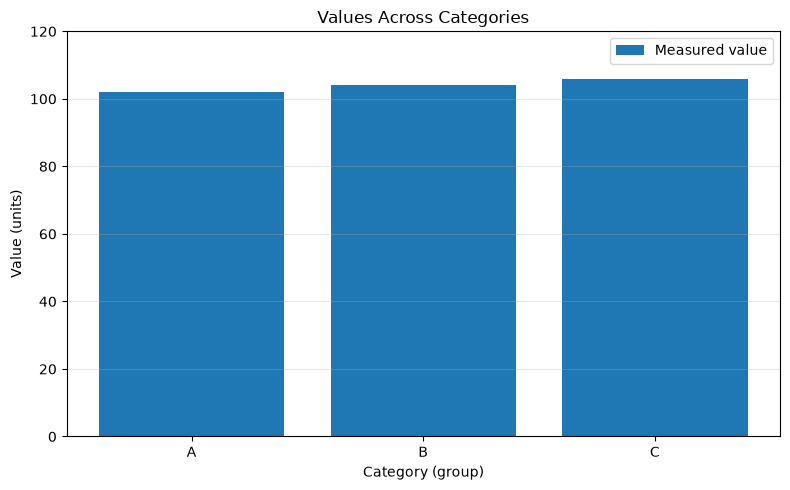

In [6]:
# TASK 04
# Fix the terrible chart

import matplotlib.pyplot as plt

# =========================================================
# 1. The terrible chart
# =========================================================

fig, ax = plt.subplots()

ax.bar(
    ["A", "B", "C"],
    [102, 104, 106],
    color=["red", "lime", "cyan"],
)

ax.set_ylim(100, 107)

plt.show()


# =========================================================
# 2. Flaws in the terrible chart
# =========================================================

# Flaws:
# 1. No title, so we do not know what the chart represents.
# 2. No x-axis label.
# 3. No y-axis label or units.
# 4. No legend or explanation of the categories.
# 5. Red, lime, and cyan colours are visually distracting.
# 6. No gridlines, making values harder to compare.
# 7. The y-axis starts at 100 instead of zero.
# 8. Starting the bar chart at 100 makes small differences
#    between 102, 104, and 106 look much larger than they are.


# =========================================================
# 3. Fixed and honest chart
# =========================================================

categories = ["A", "B", "C"]
values = [102, 104, 106]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    categories,
    values,
    label="Measured value",
)

ax.set_title("Values Across Categories")
ax.set_xlabel("Category (group)")
ax.set_ylabel("Value (units)")

# A bar chart should start at zero to represent the
# magnitude of each bar honestly.
ax.set_ylim(0, 120)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.legend()

plt.tight_layout()
plt.show()


# =========================================================
# 4. Judgment
# =========================================================

# The most misleading flaw was the y-axis starting at 100,
# because it makes the small difference between the values
# appear much larger than it really is.
#
# Misleading is worse than ugly because an ugly chart may
# simply be unpleasant to look at, while a misleading chart
# can cause people to reach the wrong conclusion from the data.

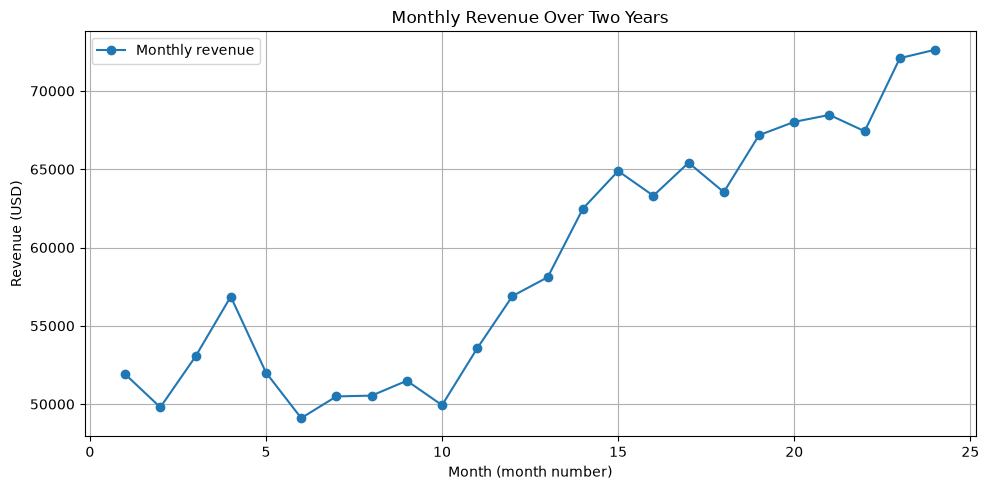

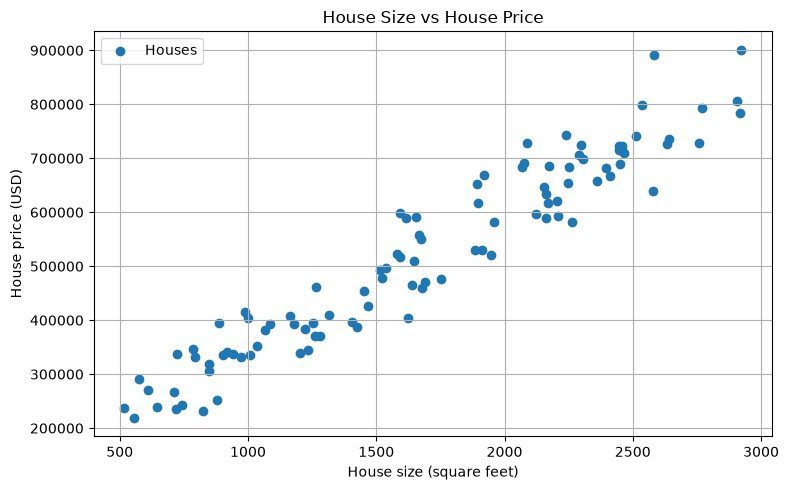

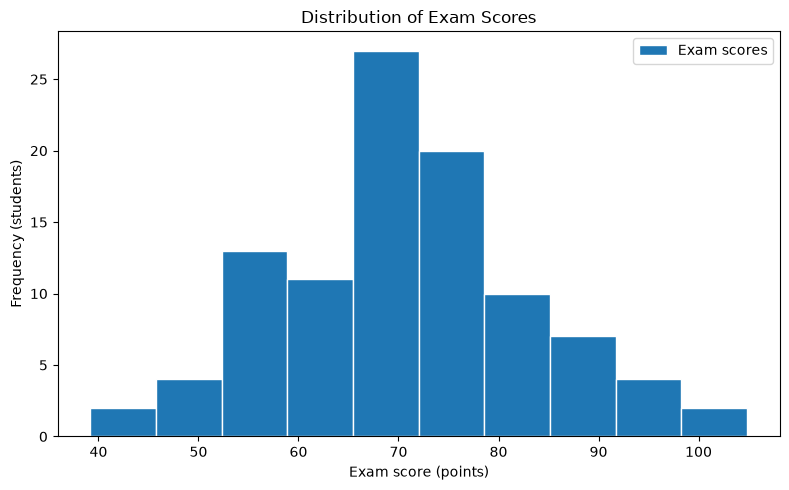

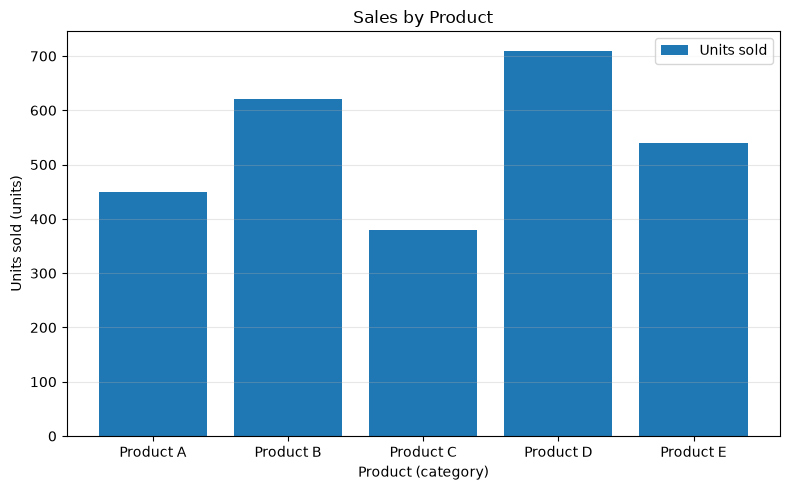

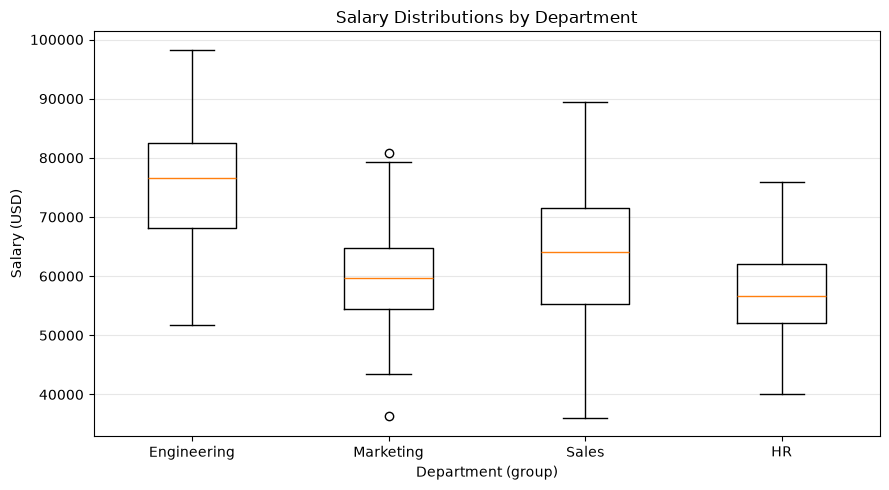

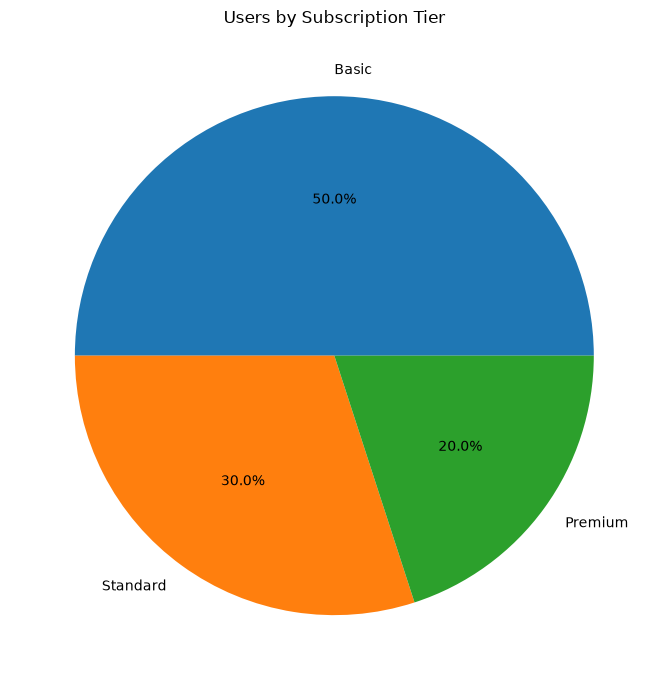

In [7]:
# TASK 05
# Choose the right plot

import numpy as np
import matplotlib.pyplot as plt

# Reproducible random data
rng = np.random.default_rng(42)


# =========================================================
# a. Monthly revenue over the past two years
# =========================================================

# Best plot: LINE
# Why: A line chart clearly shows how a value changes over time.

months = np.arange(1, 25)
revenue = 50000 + np.cumsum(rng.normal(1000, 3000, 24))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(months, revenue, marker="o", label="Monthly revenue")

ax.set_title("Monthly Revenue Over Two Years")
ax.set_xlabel("Month (month number)")
ax.set_ylabel("Revenue (USD)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


# =========================================================
# b. House size vs house price
# =========================================================

# Best plot: SCATTER
# Why: A scatter plot shows the relationship between two numerical variables.

house_size = rng.uniform(500, 3000, 100)
house_price = 100000 + house_size * 250 + rng.normal(0, 50000, 100)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(house_size, house_price, label="Houses")

ax.set_title("House Size vs House Price")
ax.set_xlabel("House size (square feet)")
ax.set_ylabel("House price (USD)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


# =========================================================
# c. Exam score distribution
# =========================================================

# Best plot: HISTOGRAM
# Why: A histogram shows how numerical scores are distributed.

exam_scores = rng.normal(70, 12, 100)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(exam_scores, bins=10, edgecolor="white", label="Exam scores")

ax.set_title("Distribution of Exam Scores")
ax.set_xlabel("Exam score (points)")
ax.set_ylabel("Frequency (students)")
ax.legend()

plt.tight_layout()
plt.show()


# =========================================================
# d. Which of five products sells the most?
# =========================================================

# Best plot: BAR CHART
# Why: A bar chart makes it easy to compare sales across categories.

products = ["Product A", "Product B", "Product C", "Product D", "Product E"]
sales = [450, 620, 380, 710, 540]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(products, sales, label="Units sold")

ax.set_title("Sales by Product")
ax.set_xlabel("Product (category)")
ax.set_ylabel("Units sold (units)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# =========================================================
# e. Salary distributions across four departments
# =========================================================

# Best plot: BOXPLOT
# Why: Boxplots compare the distributions, medians, and spread
# of several groups clearly.
#
# Possible alternative: Histograms could also compare distributions,
# but four separate histograms would take more space and be harder
# to compare directly.

engineering = rng.normal(75000, 10000, 100)
marketing = rng.normal(60000, 8000, 100)
sales_dept = rng.normal(65000, 12000, 100)
hr = rng.normal(58000, 7000, 100)

departments = [
    engineering,
    marketing,
    sales_dept,
    hr,
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(departments, tick_labels=["Engineering", "Marketing", "Sales", "HR"])

ax.set_title("Salary Distributions by Department")
ax.set_xlabel("Department (group)")
ax.set_ylabel("Salary (USD)")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# =========================================================
# f. Proportion of users on three subscription tiers
# =========================================================

# Best plot: PIE CHART
# Why: A pie chart shows how categories make up a whole.

tiers = ["Basic", "Standard", "Premium"]
users = [500, 300, 200]

fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    users,
    labels=tiers,
    autopct="%1.1f%%",
)

ax.set_title("Users by Subscription Tier")

plt.tight_layout()
plt.show()


# =========================================================
# Summary of plot choices
# =========================================================

# a. Line       -> change over time
# b. Scatter    -> relationship between two numerical variables
# c. Histogram  -> distribution of one numerical variable
# d. Bar        -> compare categories
# e. Boxplot    -> compare distributions across groups
# f. Pie        -> parts/proportions of a whole
#
# Hesitation:
# e. Boxplot vs histogram:
#    Both can show distributions, but a boxplot is better here
#    because four departments need to be compared directly.
#
# f. Pie vs bar chart:
#    Both can compare category sizes, but pie emphasizes that
#    the categories form one whole.

Part C — the polished figure

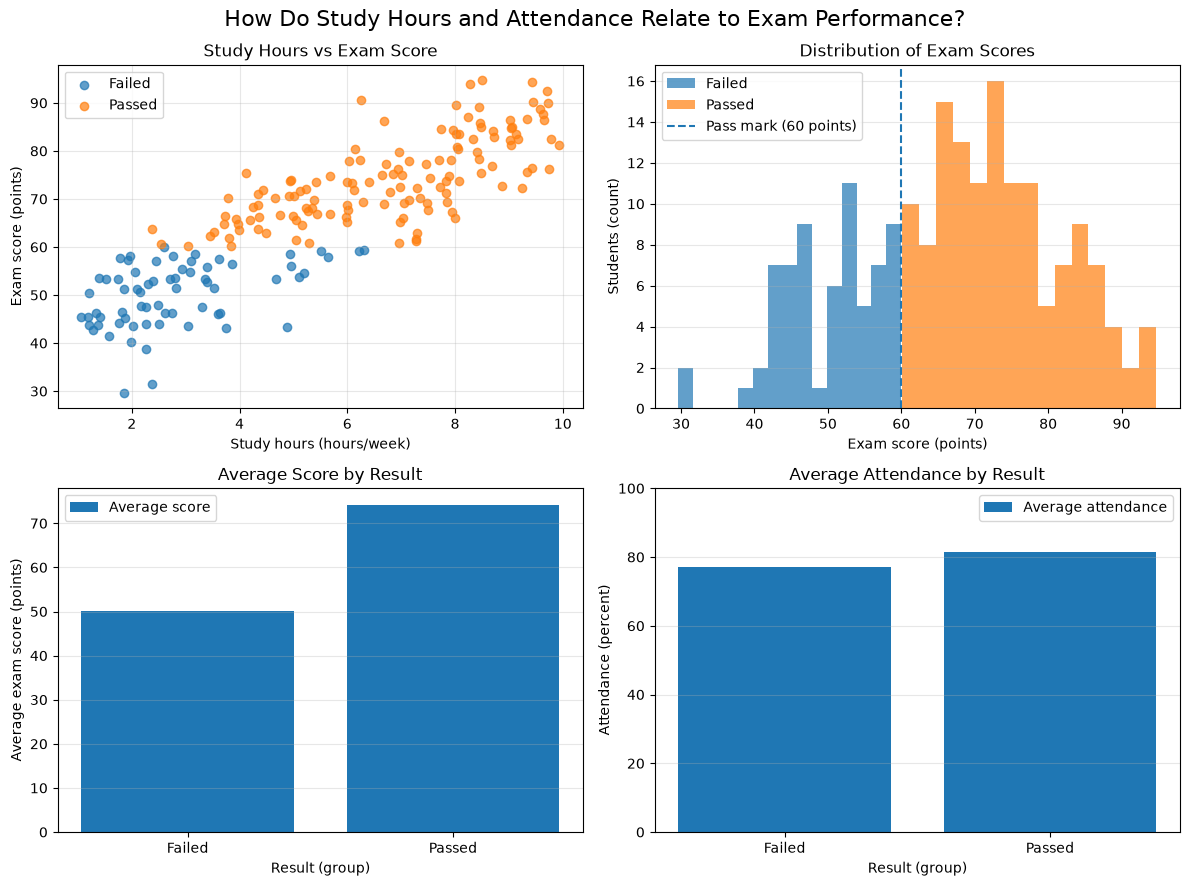

In [8]:
# TASK 06
# One report-quality figure

import numpy as np
import matplotlib.pyplot as plt

# Reproducible dataset
rng = np.random.default_rng(42)

n_students = 200

study_hours = rng.uniform(1, 10, n_students)
attendance = rng.uniform(60, 100, n_students)

# Exam score influenced by study hours and attendance, plus noise
exam_scores = (
    35
    + 4.5 * study_hours
    + 0.35 * (attendance - 60)
    + rng.normal(0, 6, n_students)
)
exam_scores = np.clip(exam_scores, 0, 100)

# Pass/fail based on score
passed = exam_scores >= 60

# Meaningful, consistent groups
pass_labels = np.where(passed, "Passed", "Failed")

# ---------------------------------------------------------
# Report-quality 2 x 2 figure
# Question:
# "How are study habits and attendance related to exam
# performance and passing?"
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Panel 1: Scatter — study hours vs exam score
axes[0, 0].scatter(
    study_hours[~passed],
    exam_scores[~passed],
    alpha=0.7,
    label="Failed",
)
axes[0, 0].scatter(
    study_hours[passed],
    exam_scores[passed],
    alpha=0.7,
    label="Passed",
)

axes[0, 0].set_title("Study Hours vs Exam Score")
axes[0, 0].set_xlabel("Study hours (hours/week)")
axes[0, 0].set_ylabel("Exam score (points)")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)


# Panel 2: Histogram — exam score distribution
axes[0, 1].hist(
    exam_scores[~passed],
    bins=15,
    alpha=0.7,
    label="Failed",
)
axes[0, 1].hist(
    exam_scores[passed],
    bins=15,
    alpha=0.7,
    label="Passed",
)

axes[0, 1].axvline(
    60,
    linestyle="--",
    label="Pass mark (60 points)",
)

axes[0, 1].set_title("Distribution of Exam Scores")
axes[0, 1].set_xlabel("Exam score (points)")
axes[0, 1].set_ylabel("Students (count)")
axes[0, 1].legend()
axes[0, 1].grid(axis="y", alpha=0.3)


# Panel 3: Bar — average score by pass/fail
group_means = [
    exam_scores[~passed].mean(),
    exam_scores[passed].mean(),
]

axes[1, 0].bar(
    ["Failed", "Passed"],
    group_means,
    label="Average score",
)

axes[1, 0].set_title("Average Score by Result")
axes[1, 0].set_xlabel("Result (group)")
axes[1, 0].set_ylabel("Average exam score (points)")
axes[1, 0].legend()
axes[1, 0].grid(axis="y", alpha=0.3)


# Panel 4: Bar — average attendance by pass/fail
attendance_means = [
    attendance[~passed].mean(),
    attendance[passed].mean(),
]

axes[1, 1].bar(
    ["Failed", "Passed"],
    attendance_means,
    label="Average attendance",
)

axes[1, 1].set_title("Average Attendance by Result")
axes[1, 1].set_xlabel("Result (group)")
axes[1, 1].set_ylabel("Attendance (percent)")
axes[1, 1].set_ylim(0, 100)
axes[1, 1].legend()
axes[1, 1].grid(axis="y", alpha=0.3)


# Whole figure title
fig.suptitle(
    "How Do Study Hours and Attendance Relate to Exam Performance?",
    fontsize=16,
)

plt.tight_layout()

# Save report-quality PNG
fig.savefig(
    "report_figure.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------
# Two-sentence report caption
# ---------------------------------------------------------

# This figure shows how study hours and attendance relate to
# students' exam scores and pass/fail outcomes across 200 students.
#
# The main takeaway is that students who passed generally show
# stronger exam performance and higher study/attendance measures.
